# LeetCode #515: Find Largest Value in Each Tree Row

https://leetcode.com/problems/find-largest-value-in-each-tree-row/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (DFS + depth map)** | $O(n)$ | $O(n)$ |
| **Optimal: BFS Level Order ★** | $O(n)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force (DFS + depth map)
DFS while maintaining a map from depth → current max. Update each level's max as nodes are visited. Requires an auxiliary map and a separate pass at the end to collect values in order.

### Optimal: BFS Level Order ★
BFS processes nodes level by level; track the running max within each level's batch. Append the max when the level is exhausted. No auxiliary map needed.

**Why this is better than Brute Force:** No hash map overhead — max value is computed in-place as each level is processed, and results emerge in natural order.

**Constraints:**
* The number of nodes in the tree is in the range $[0, 10^4]$.
* $-2^{31} \le$ Node.val $\le 2^{31} - 1$

## Solutions

### C#

In [ ]:
public IList<int> LargestValues(TreeNode root) {
    var result = new List<int>();
    if (root == null) return result;
    var queue = new Queue<TreeNode>();
    queue.Enqueue(root);
    while (queue.Count > 0) {
        int sz = queue.Count, max = int.MinValue;
        while (sz-- > 0) {
            var node = queue.Dequeue();
            // Track running maximum for this level
            max = Math.Max(max, node.val);
            if (node.left  != null) queue.Enqueue(node.left);
            if (node.right != null) queue.Enqueue(node.right);
        }
        result.Add(max);
    }
    return result;
}

### Python

In [ ]:
from collections import deque

def largestValues(self, root: Optional[TreeNode]) -> List[int]:
    if not root:
        return []
    result, queue = [], deque([root])
    while queue:
        level_max = float('-inf')
        for _ in range(len(queue)):
            node = queue.popleft()
            # Track running maximum for this level
            level_max = max(level_max, node.val)
            if node.left:  queue.append(node.left)
            if node.right: queue.append(node.right)
        result.append(level_max)
    return result

### Go

In [ ]:
import "math"

func largestValues(root *TreeNode) []int {
    if root == nil { return nil }
    result := []int{}
    queue := []*TreeNode{root}
    for len(queue) > 0 {
        sz, maxVal := len(queue), math.MinInt32
        for i := 0; i < sz; i++ {
            node := queue[i]
            // Track running maximum for this level
            if node.Val > maxVal { maxVal = node.Val }
            if node.Left  != nil { queue = append(queue, node.Left) }
            if node.Right != nil { queue = append(queue, node.Right) }
        }
        queue = queue[sz:]
        result = append(result, maxVal)
    }
    return result
}

### Rust

In [ ]:
pub fn largest_values(root: Option<Rc<RefCell<TreeNode>>>) -> Vec<i32> {
    let mut result = vec![];
    let mut queue = std::collections::VecDeque::new();
    if let Some(r) = root { queue.push_back(r); }
    while !queue.is_empty() {
        let mut level_max = i32::MIN;
        for _ in 0..queue.len() {
            let node = queue.pop_front().unwrap();
            let (val, l, r) = { let b = node.borrow(); (b.val, b.left.clone(), b.right.clone()) };
            // Track running maximum for this level
            level_max = level_max.max(val);
            if let Some(l) = l { queue.push_back(l); }
            if let Some(r) = r { queue.push_back(r); }
        }
        result.push(level_max);
    }
    result
}

## Example Scenarios

**1. Common Case**
**Input:** root = [1,3,2,5,3,null,9]
Level 0 max=1. Level 1 max=max(3,2)=3. Level 2 max=max(5,3,9)=9. Result: **[1,3,9]**.

**2. Slightly Complex**
**Input:** root = [1,-1,-2,3,-3,null,-4]
Level 0: 1. Level 1: max(-1,-2)=-1. Level 2: max(3,-3,-4)=3. Result: **[1,-1,3]** — negative values require initializing max to $-\infty$ (or `int.MinValue`).

**3. Edge Case: Time Factor**
**Input:** A right-skewed tree [1,null,2,null,...,null,n]
BFS visits every node in its own level (one node per level). $n$ iterations, each $O(1)$: total $O(n)$ time, but the per-level loop degenerates to checking a single node $n$ times.

**4. Edge Case: Space Factor**
**Input:** A complete binary tree where the last level has $\approx n/2$ nodes
All $n/2 \approx 5000$ nodes are enqueued simultaneously, peaking at $O(n)$ queue space. Result has $\log_2 n \approx 14$ entries.

**5. Almost-Impossible but Plausible**
**Input:** root = [-2147483648] (single node, minimum int32)
Initializing `max = int.MinValue` and comparing gives max = $-2^{31}$. Result: **[-2147483648]**. Tests that `int.MinValue` as an initial sentinel doesn't accidentally pass when a node equals it.

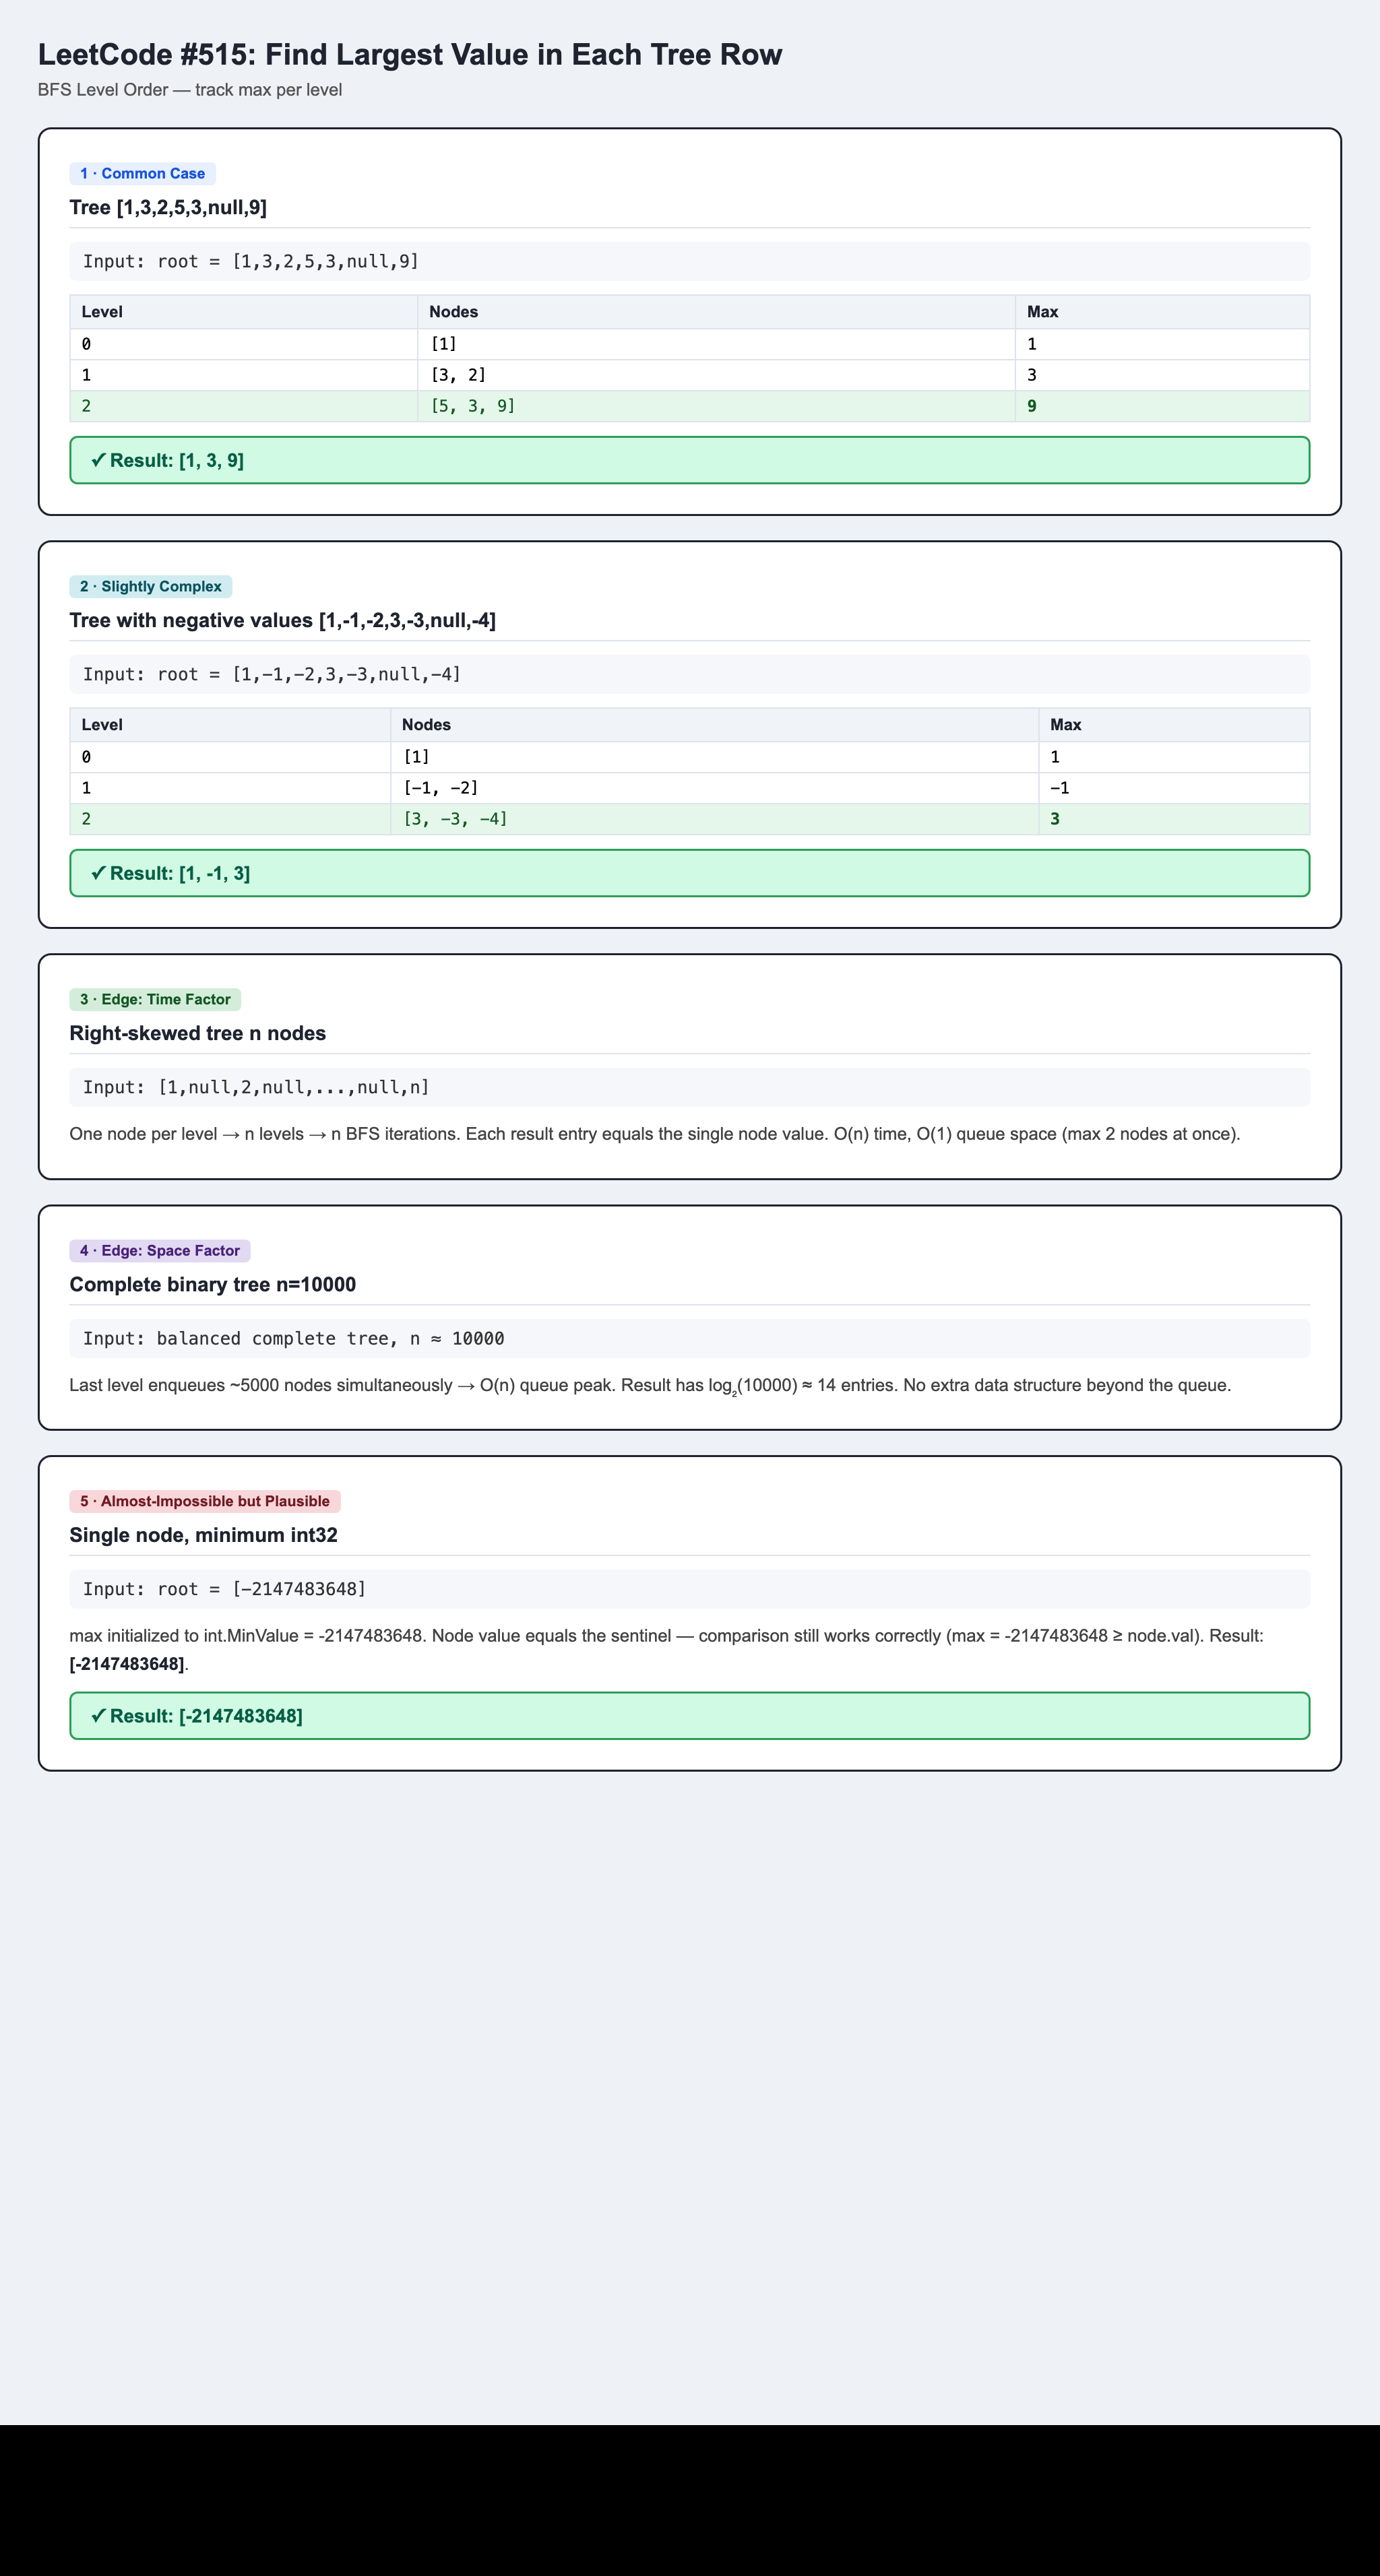